# Skills for AI assignment: Neural Network

### Step 0: Find 3 papers on the topic (ex: MNIST dataset)

### Step 1: Define three characters

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence
import pandas as pd

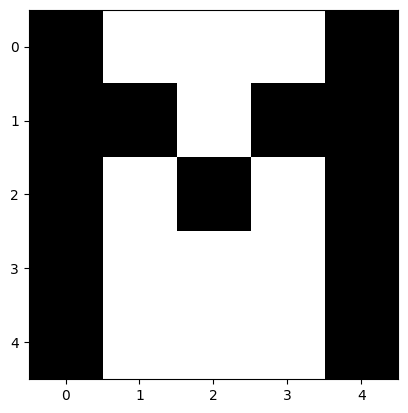

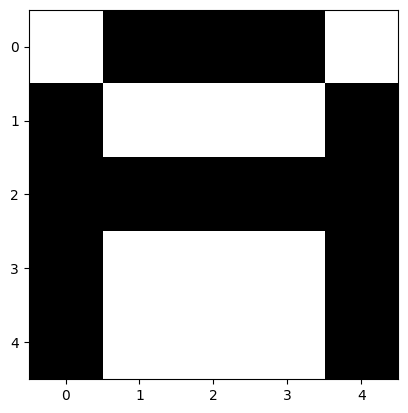

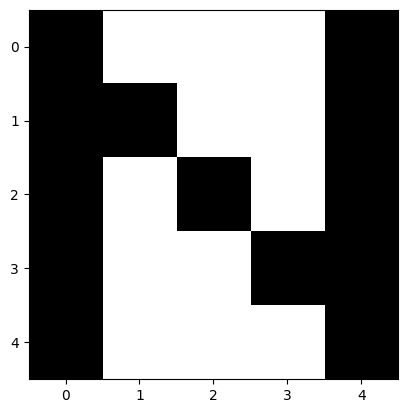

In [4]:
# Define characters (M,A,N)
# Letter M
M = np.array([
    [1,0,0,0,1],
    [1,1,0,1,1],
    [1,0,1,0,1],
    [1,0,0,0,1],
    [1,0,0,0,1]
])

# Letter A
A = np.array([
    [0,1,1,1,0],
    [1,0,0,0,1],
    [1,1,1,1,1],
    [1,0,0,0,1],
    [1,0,0,0,1]
])

# Letter N
N = np.array([
    [1,0,0,0,1],
    [1,1,0,0,1],
    [1,0,1,0,1],
    [1,0,0,1,1],
    [1,0,0,0,1]
])

plt.imshow(M, 'gray_r')
plt.show()
plt.imshow(A, 'gray_r')
plt.show()
plt.imshow(N, 'gray_r')
plt.show()


### Step 2: Create variations of the letters

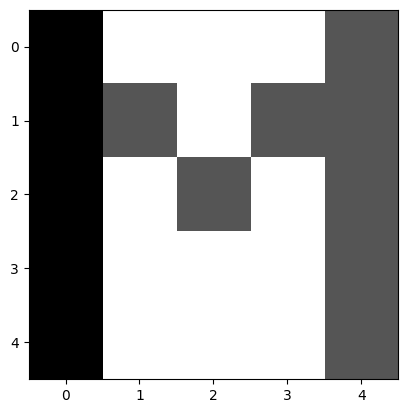

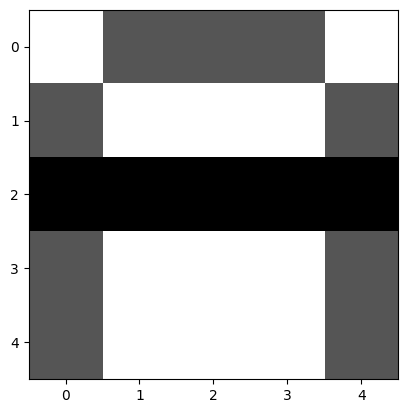

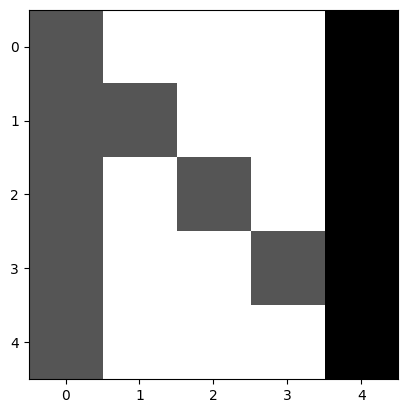

In [5]:
# variation 1: Emphasise one line

# Letter M
M_emph = np.array([
    [1.5,0,0,0,1],
    [1.5,1,0,1,1],
    [1.5,0,1,0,1],
    [1.5,0,0,0,1],
    [1.5,0,0,0,1]
])

# Letter A
A_emph = np.array([
    [0,1,1,1,0],
    [1,0,0,0,1],
    [1.5,1.5,1.5,1.5,1.5],
    [1,0,0,0,1],
    [1,0,0,0,1]
])

# Letter N
N_emph = np.array([
    [1,0,0,0,1.5],
    [1,1,0,0,1.5],
    [1,0,1,0,1.5],
    [1,0,0,1,1.5],
    [1,0,0,0,1.5]
])

plt.imshow(M_emph, 'gray_r')
plt.show()
plt.imshow(A_emph, 'gray_r')
plt.show()
plt.imshow(N_emph, 'gray_r')
plt.show()

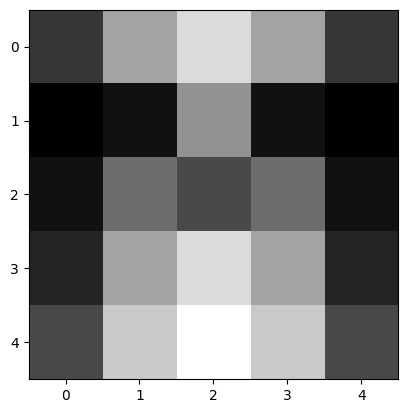

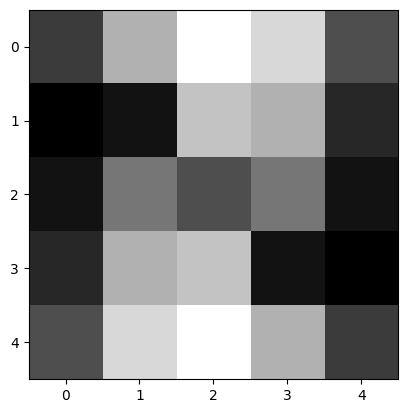

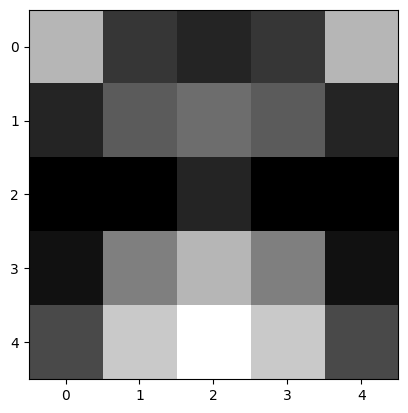

In [ ]:
# Variation 2: blur with gaussian kernel
blur_filter = np.array([
    [1,2,1],
    [2,8,2],
    [1,2,1]
])

def apply_filter(image, filter):
    padded_image = np.pad(image, 1)
    output = np.ones((5,5))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            
            # get 3x3 patch
            patch = padded_image[i:i+3, j:j+3]
            output[i,j] = np.sum(patch * filter)

    return output

#display(M)
M_blur = apply_filter(M, blur_filter/np.sum(blur_filter)) 
plt.imshow(M_blur, 'gray_r')
plt.show()

N_blur = apply_filter(N, blur_filter/np.sum(blur_filter))
plt.imshow(N_blur, 'gray_r')
plt.show()

A_blur = apply_filter(A, blur_filter/np.sum(blur_filter))
plt.imshow(A_blur, 'gray_r')
plt.show()



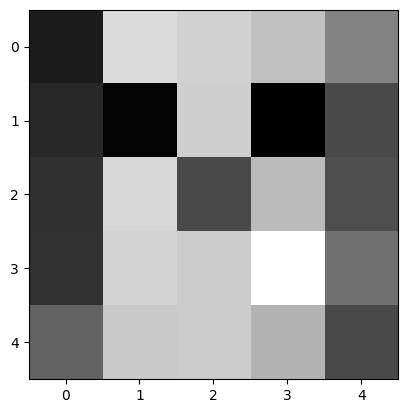

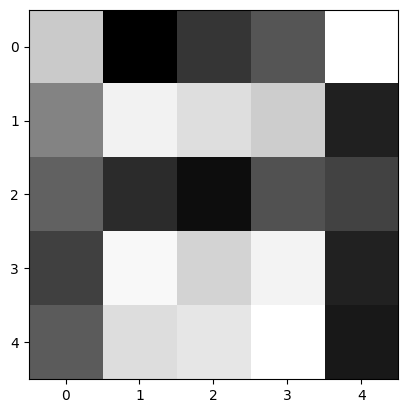

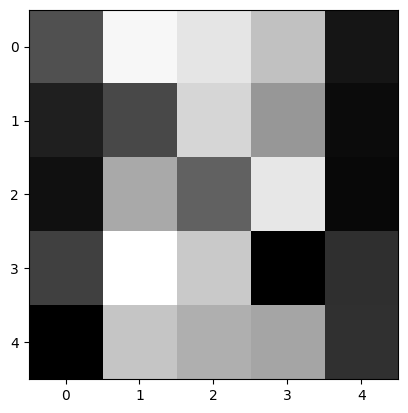

In [9]:
# Varriant 3: Random noise

def add_noise_image(image):
    output = np.zeros(image.shape)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i,j] = image[i,j] + np.random.normal(loc=0,scale=0.2)

    return output

M_noise = add_noise_image(M)
plt.imshow(M_noise, 'gray_r')
plt.show()

A_noise = add_noise_image(A)
plt.imshow(A_noise, 'gray_r')
plt.show()

N_noise = add_noise_image(N)
plt.imshow(N_noise, 'gray_r')
plt.show()



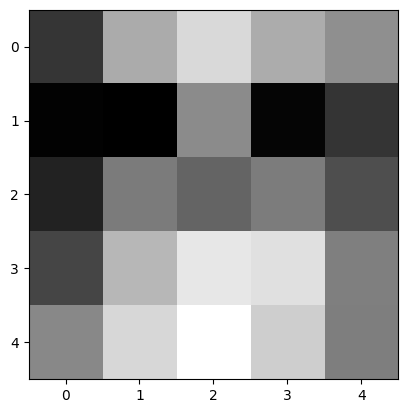

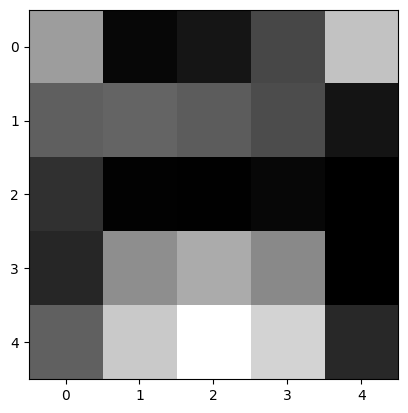

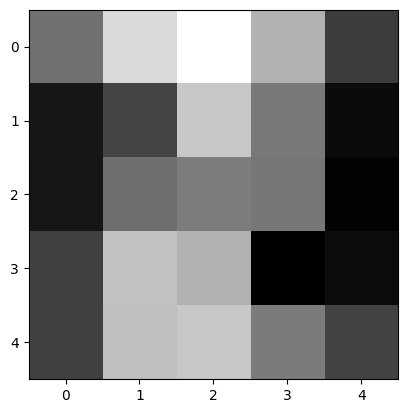

In [11]:
# variant 4: noise + blur
M_blur_noise = apply_filter(M_noise, blur_filter)
A_blur_noise = apply_filter(A_noise, blur_filter)
N_blur_noise = apply_filter(N_noise, blur_filter)

plt.imshow(M_blur_noise, 'gray_r')
plt.show()

plt.imshow(A_blur_noise, 'gray_r')
plt.show()

plt.imshow(N_blur_noise, 'gray_r')
plt.show()

### Step 3: Create the correlation matrix with the inproducts between all the variants of M, A, and N

In [89]:
# inproducts 

In [14]:
def corr_matrix(inputs: Sequence[dict]):
    corr_shape = len(inputs) #* len(inputs[0]["char"].flatten())
    out = np.zeros((corr_shape, corr_shape))
    for i in range(len(inputs)):
        for j in range(len(inputs)):
            vec1 = inputs[i]["char"].flatten()
            label1 = inputs[i]["label"]
            vec2 = inputs[j]["char"].flatten()
            label2 = inputs[j]["label"]
            out[i, j] = np.dot(vec1, vec2)
    return out

def visualize_corr_matrix(inputs: Sequence[dict], fontsize = 1):
    corr_mat = corr_matrix(inputs)
    for i in range(corr_mat.shape[0]):
        for j in range(corr_mat.shape[1]):
            plt.text(i, j, str(corr_mat[i, j]), ha="center", va="center", color="r", fontsize=fontsize )
    plt.imshow(corr_mat, "grey_r")
    plt.show()

dict_M = {"char": M,
          "label": "M original"}
dict_A = {"char": A,
          "label": "A original"}
dict_N = {"char": N,
          "label": "N original"}

dict_M_emph = {"char": M_emph,
          "label": "M original"}
dict_A_emph = {"char": A_emph,
          "label": "A original"}
dict_N_emph = {"char": N_emph,
          "label": "N original"}

dict_M_blur = {"char": M_blur*10,
          "label": "M original"}
dict_A_blur = {"char": A_blur * 10,
          "label": "A original"}
dict_N_blur = {"char": N_blur * 10,
          "label": "N original"}

dict_M_noise = {"char": M_noise,
          "label": "M original"}
dict_A_noise = {"char": A_noise,
          "label": "A original"}
dict_N_noise = {"char": N_noise,
          "label": "N original"}

dict_M_blur_noise = {"char": M_blur_noise,
          "label": "M original"}
dict_A_blur_noise = {"char": A_blur_noise,
          "label": "A original"}
dict_N_blur_noise = {"char": N_blur_noise,
          "label": "N original"}

inputs = [dict_M_emph, dict_M_blur, dict_M_noise, dict_M_blur_noise, dict_A_emph, dict_A_blur, dict_A_noise, dict_A_blur_noise, dict_N_emph, dict_N_blur, dict_N_noise, dict_N_blur_noise]
for inp in inputs:
    print(inp["char"])
    print("")
# print(dict_M_blur_noise["char"])
# cor_mat = corr_matrix(inputs)
# visualize_corr_matrix(inputs)

[[1.5 0.  0.  0.  1. ]
 [1.5 1.  0.  1.  1. ]
 [1.5 0.  1.  0.  1. ]
 [1.5 0.  0.  0.  1. ]
 [1.5 0.  0.  0.  1. ]]

[[55. 25. 10. 25. 55.]
 [70. 65. 30. 65. 70.]
 [65. 40. 50. 40. 65.]
 [60. 25. 10. 25. 60.]
 [50. 15.  0. 15. 50.]]

[[ 1.16972009 -0.02459456  0.03671127  0.14718551  0.52689393]
 [ 1.0843509   1.31913571  0.04930644  1.34418703  0.88336401]
 [ 1.03564392  0.00346253  0.88451298  0.17649635  0.85697133]
 [ 1.02942117  0.02234868  0.07063195 -0.25126069  0.64337778]
 [ 0.72163867  0.08900499  0.06981966  0.22685602  0.89072725]]

[[12.79640907  5.98803497  3.30080767  5.92573898  7.62043747]
 [15.70267462 15.90472453  7.86609531 15.57129036 12.8466985 ]
 [13.86110498  8.7846933  10.11030911  8.72747229 11.35517325]
 [11.88709944  5.27544596  2.51171673  2.92666993  8.54325042]
 [ 8.03231037  3.43970706  1.10263117  3.94743032  8.61502492]]

[[0.  1.  1.  1.  0. ]
 [1.  0.  0.  0.  1. ]
 [1.5 1.5 1.5 1.5 1.5]
 [1.  0.  0.  0.  1. ]
 [1.  0.  0.  0.  1. ]]

[[2.  5.5 6.  5